In [2]:
import pandas as pd                             # pandas
import numpy as np                              # numpy
import matplotlib.pyplot as plt                 # matplotlib
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # - 깨짐 방지
data1 = pd.read_csv('./kdrama.csv')             # 드라마 데이터 가져오기

In [3]:
# 컬럼명 한글로 변환
data1 = data1.rename(columns={
    "Name": "작품명","Aired Date": "방영 기간","Year of release": "공개 연도","Original Network": "원작 방송사","Aired On": "방영 요일"
    , "Number of Episodes": "총 에피 수","Duration": "회당 러닝타임","Content Rating": "시청 등급", "Rating": "평점","Synopsis": "줄거리"
    , "Genre": "장르","Tags": "태그","Director": "감독","Screenwriter": "각본","Cast": "출연진","Production companies": "제작사","Rank": "순위"
})
# 전체 장르명 한글로 변환해줄 딕셔너리
genre_kr = {
    'Romance': '로맨스','Drama': '드라마','Mystery': '미스터리','Comedy': '코미디','Thriller': '스릴러','Life': '일상','Action': '액션'
    ,'Melodrama': '멜로드라마','Historical': '사극','Fantasy': '판타지','Law': '법정','Crime': '범죄','Supernatural': '초자연','Psychological': '심리'
    ,'Political': '정치','Youth': '청춘','Medical': '의학','Family': '가족','Horror': '공포','Sci-Fi': 'SF','Friendship': '우정'
    ,'Business': '비즈니스','Sports': '스포츠','Military': '군대','Music': '음악','Adventure': '모험','Food': '음식','School': '학원','Sitcom': '시트콤'
}

def translate_genres(genre_str):
    if pd.isna(genre_str):
        return genre_str

    genres = [g.strip() for g in genre_str.split(',')]
    return ', '.join(genre_kr.get(g, g) for g in genres)

data1['장르'] = data1['장르'].apply(translate_genres)
data1['장르']

0              일상, 드라마, 가족
1      스릴러, 로맨스, 범죄, 멜로드라마
2          우정, 로맨스, 일상, 의학
3          우정, 로맨스, 일상, 의학
4          심리, 일상, 드라마, 가족
              ...         
245       사극, 로맨스, 의학, 판타지
246     사극, 로맨스, 멜로드라마, 정치
247       법정, 로맨스, 일상, 드라마
248      공포, 코미디, 로맨스, 판타지
249      액션, 스릴러, 미스터리, 범죄
Name: 장르, Length: 250, dtype: object

In [4]:
# 필요한 컬럼만 가져와서 DataFrame 새로 만들기
df1 = data1[['작품명', '장르', '공개 연도', '평점', '순위']].copy()
# 2010년 이전의 데이터는 데이터의 크기가 너무 작아 유의미한 의미를 가지지 못할것 같아 2010년 이전 데이터는 전부 제외
df1 = df1[df1['공개 연도'] >= 2010]                                
df1

,작품명,장르,공개 연도,평점,순위
0,Move to Heaven,"일상, 드라마, 가족",2021,9.2,#1
1,Flower of Evil,"스릴러, 로맨스, 범죄, 멜로드라마",2020,9.1,#2
2,Hospital Playlist,"우정, 로맨스, 일상, 의학",2020,9.1,#3
3,Hospital Playlist 2,"우정, 로맨스, 일상, 의학",2021,9.1,#4
4,My Mister,"심리, 일상, 드라마, 가족",2018,9.1,#5
...,...,...,...,...,...
245,Live Up to Your Name,"사극, 로맨스, 의학, 판타지",2017,8.3,#246
246,Queen for Seven Days,"사극, 로맨스, 멜로드라마, 정치",2017,8.3,#247
247,Memory,"법정, 로맨스, 일상, 드라마",2016,8.3,#248
248,A Korean Odyssey,"공포, 코미디, 로맨스, 판타지",2017,8.3,#249


# 가설2. 사회불안요소가 장르 선호도 변화와 연관이 있을까?
## 그룹핑 : 국정농단사건 전 : 2010 - 2016 / 국정농단사건 후 : 2017 - 2020 
## / 코로나 사태 : 2020 - 2022 

In [41]:
ur1 = df1[(df1['공개 연도'] >= 2010) & (df1['공개 연도'] <= 2016)]
ur2 = df1[(df1['공개 연도'] > 2016) & (df1['공개 연도'] <= 2020)]
ur3 = df1[df1['공개 연도'] > 2020]

In [42]:
# 1. 2016년까지의 데이터 문자열로 변환 개행 시켜주는 이스케이프 문자 제거
# 2. ','를 기준으로 분리 
# 3. 공백 제거
# 4. 몇개인지 세주고
# 5. 그중에 indcx를 뽑아서 리스트화
ur1_g = ur1['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ur2_g = ur2['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ur3_g = ur3['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()

In [43]:
def makeDf(df, g, store, name):
    dic = {}
    for i in g:
        dic[i] = df[df['장르'].str.contains(i)]['평점']

    store[name] = pd.DataFrame({
        '갯수': {genre: len(ratings) for genre, ratings in dic.items()},
        '평균 평점': {genre: ratings.mean() for genre, ratings in dic.items()},
        '선호도': {genre: (ratings.mean()
                        * np.log(len(ratings) + 1)
                       ) 
                for genre, ratings in dic.items()}
    })

    store[name]['평균 평점'] = store[name]['평균 평점'].round(2)
    store[name]['선호도'] = store[name]['선호도'].round(2)

    store[name] = store[name].sort_values('선호도', ascending=False)

In [44]:
# 차트 그리는 함수  
def draw_chart(x,y,t):             # 매개변수 x => x축 / y => y축 / t => 차트 제목
    plt.figure(figsize=(12, 6))    # 차트 크기 키우고
    plt.xticks(rotation=45)        # x축의 이름 45도 기울이기 ==> 보기 편하게
    plt.grid(True, linestyle='--', alpha=0.6)     # 점선 넣기
    plt.title(t)
    plt.xlabel("장르")
    plt.ylabel("선호도")
    plt.text(0.65, 0.95,'선호도 = 평균 평점 × log(작품 수 + 1)',
        transform = plt.gca().transAxes,
        fontsize = 13,
        verticalalignment='top')
    plt.bar(x,y)                        # 차트에 x축 y축에 데이터 넣기
    # plt.show()                           # 차트 그리기

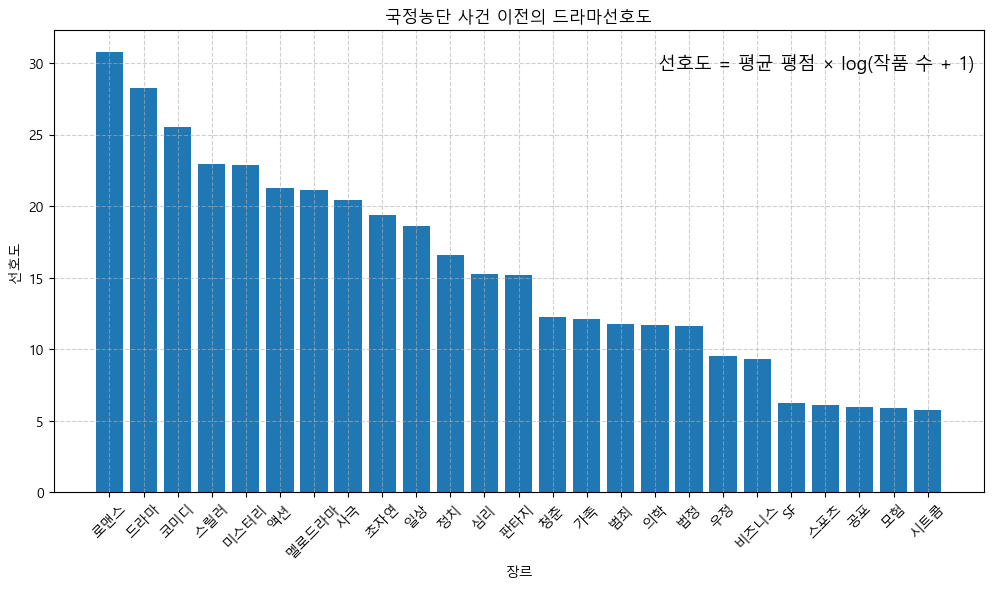

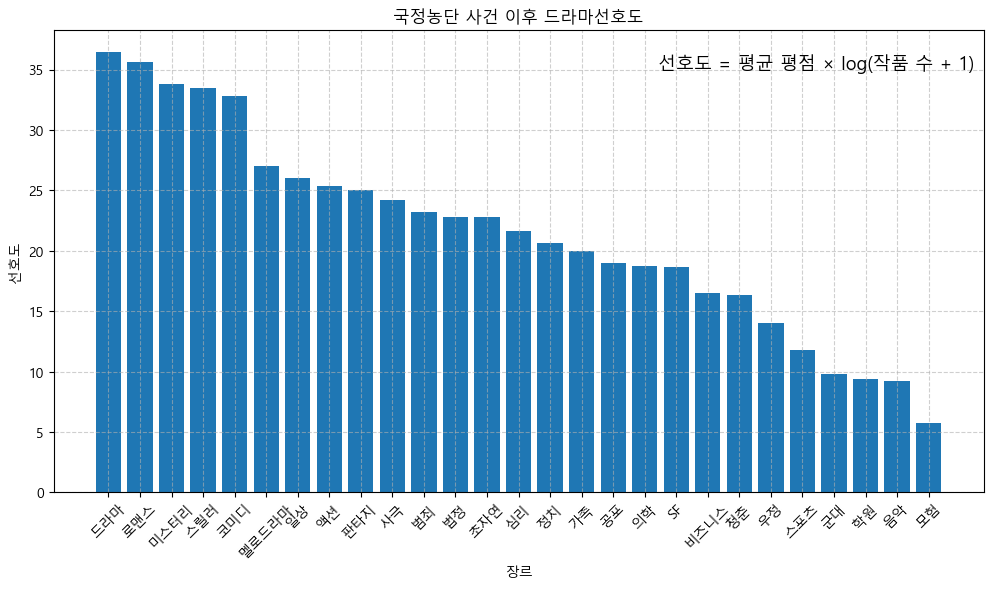

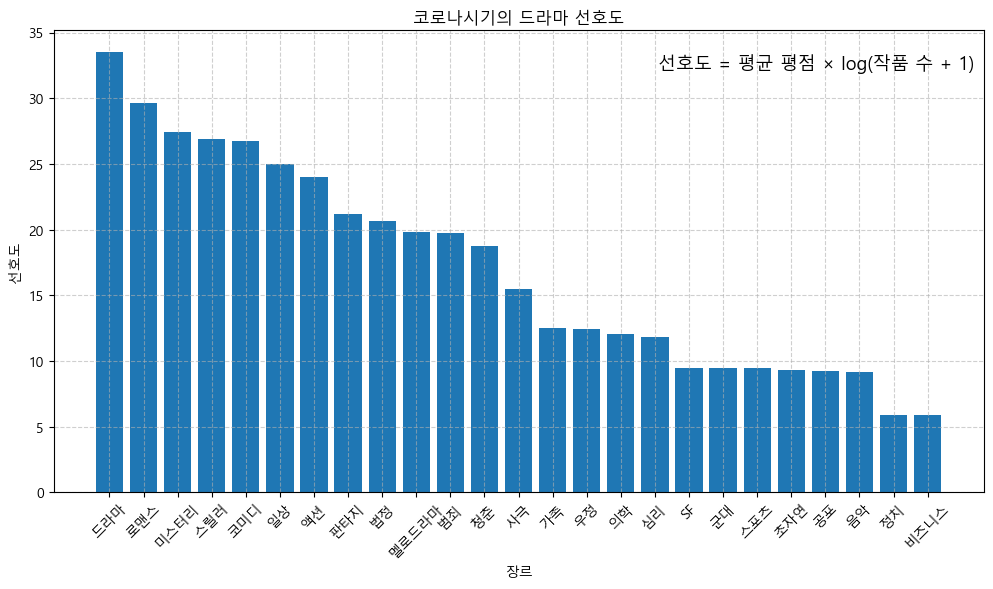

In [59]:
summary_store = {}

makeDf(ur1, ur1_g, summary_store, '농단전')
makeDf(ur2, ur2_g, summary_store, '농단후')
makeDf(ur3, ur3_g, summary_store, '코로나')

ur1_summary = summary_store['농단전']
ur2_summary = summary_store['농단후']
ur3_summary = summary_store['코로나']

x1 = ur1_summary.index.to_list()
y1 = ur1_summary['선호도'].values
draw_chart(x1,y1,'국정농단 사건 이전의 드라마선호도')

x2 = ur2_summary.index.to_list()
y2 = ur2_summary['선호도'].values
draw_chart(x2,y2,'국정농단 사건 이후 드라마선호도')

x3 = ur3_summary.index.to_list()
y3 = ur3_summary['선호도'].values
draw_chart(x3,y3,'코로나시기의 드라마 선호도')

scores = pd.DataFrame({
    "국정농단 사건 이전의 드라마선호도": ur1_summary["선호도"],
    "국정농단 사건 이후 드라마선호도": ur2_summary["선호도"],
    "코로나시기의 드라마 선호도": ur3_summary["선호도"],
}).fillna(0)

ranks = scores.rank(ascending=False, method="min")


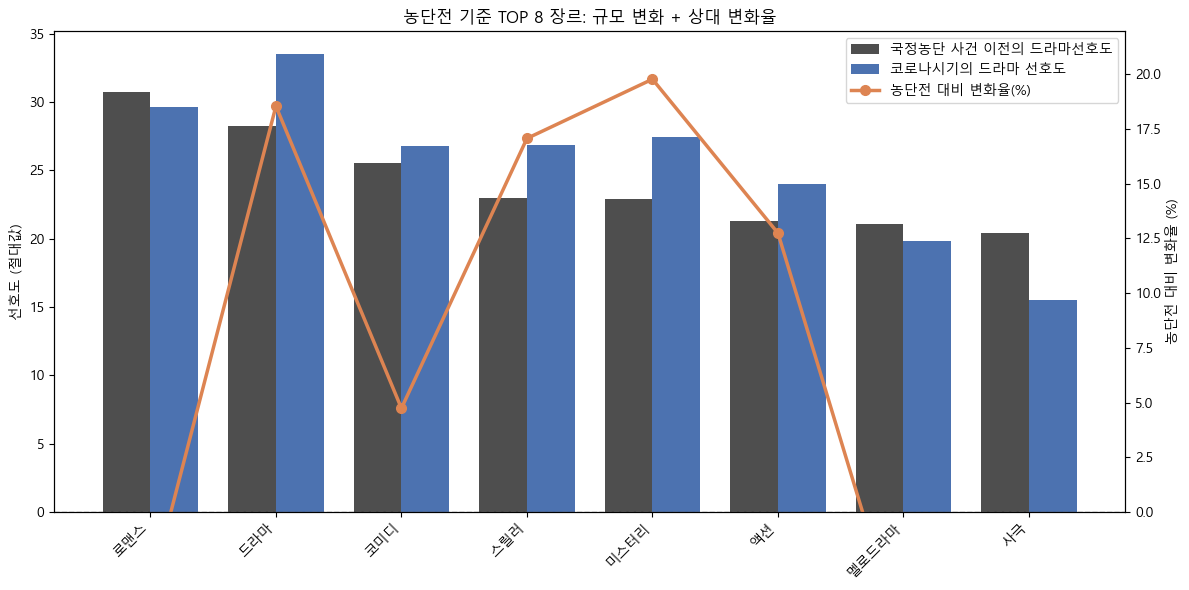

In [74]:
# 1) 데이터 준비 (절대값)
df = scores[["국정농단 사건 이전의 드라마선호도", "코로나시기의 드라마 선호도"]].copy()
df = df[(df["국정농단 사건 이전의 드라마선호도"] > 0) & (df["코로나시기의 드라마 선호도"] > 0)]

# 2) 출시전 기준 TOP 8
df_top8 = (
    df.sort_values("국정농단 사건 이전의 드라마선호도", ascending=False)
      .head(8)
)

# 3) 변화율(%)
df_top8["변화율(%)"] = (
    (df_top8["코로나시기의 드라마 선호도"] - df_top8["국정농단 사건 이전의 드라마선호도"])
    / df_top8["국정농단 사건 이전의 드라마선호도"]
) * 100

# 4) x축
genres = df_top8.index.tolist()
x = np.arange(len(genres))
w = 0.38

# 5) 그래프
fig, ax1 = plt.subplots(figsize=(12, 6))

# 🎨 (A) 출시전 막대 – 진한 회색
ax1.bar(
    x - w/2,
    df_top8["국정농단 사건 이전의 드라마선호도"],
    w,
    label="국정농단 사건 이전의 드라마선호도",
    color="#4E4E4E"
)

# 🎨 (B) 대중화 막대 – 파란색
ax1.bar(
    x + w/2,
    df_top8["코로나시기의 드라마 선호도"],
    w,
    label="코로나시기의 드라마 선호도",
    color="#4C72B0"
)
ax1.set_ylim(bottom=0)
ax1.set_ylabel("선호도 (절대값)")
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha="right")

# 🎨 (C) 변화율 선 – 빨간색 + 마커 강조
ax2 = ax1.twinx()
ax2.plot(
    x,
    df_top8["변화율(%)"],
    color="#DD8452",
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="농단전 대비 변화율(%)"
)
ax2.set_ylim(bottom=0)
ax2.axhline(0, linewidth=1, linestyle="--", color="gray")
ax2.set_ylabel("농단전 대비 변화율 (%)")

# 범례 통합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.title("농단전 기준 TOP 8 장르: 규모 변화 + 상대 변화율")
plt.tight_layout()
plt.show()

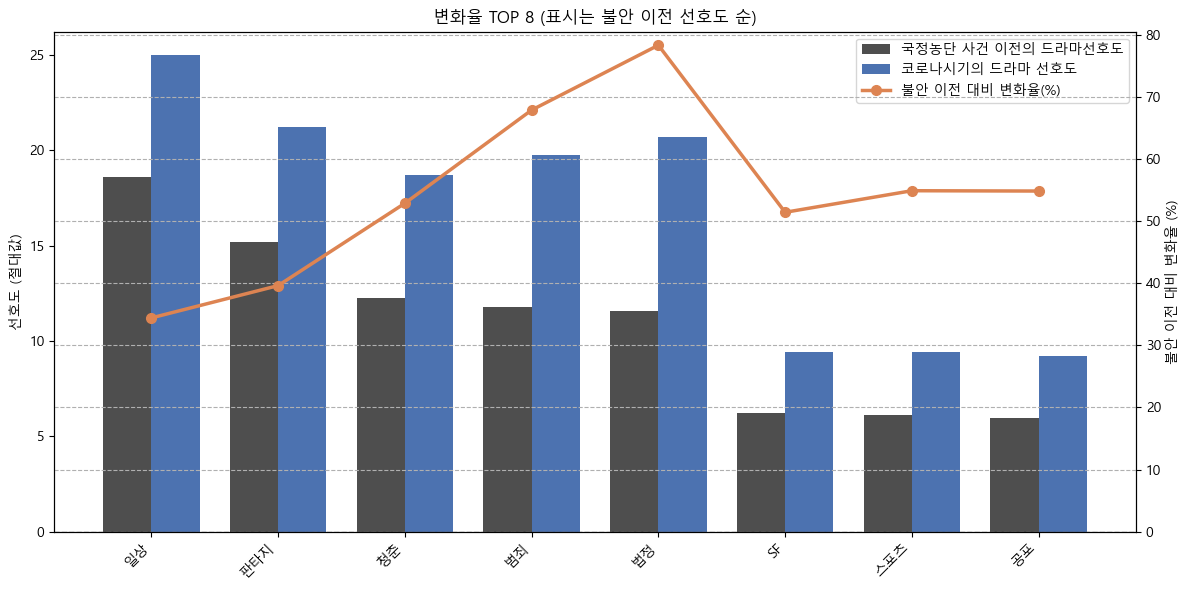

In [78]:
import numpy as np
import matplotlib.pyplot as plt

base_col = "국정농단 사건 이전의 드라마선호도"
comp_col = "코로나시기의 드라마 선호도"

# 1) 데이터 준비 (절대값)
df = scores[[base_col, comp_col]].copy()
df = df[(df[base_col] > 0) & (df[comp_col] > 0)].copy()

# 2) 변화율(%) 먼저 계산 (전체에서)
df["변화율(%)"] = ((df[comp_col] - df[base_col]) / df[base_col]) * 100

# 3) 증가한 장르만
df_inc = df[df["변화율(%)"] > 0].copy()

# 4) 변화율(%) TOP 8 선정
top8_by_growth = df_inc.sort_values("변화율(%)", ascending=False).head(8)

# 5) 표시 순서는 불안 이전(베이스) 선호도 기준 정렬(가독성)
df_top8 = top8_by_growth.sort_values(base_col, ascending=False)

# 6) x축
genres = df_top8.index.tolist()
x = np.arange(len(genres))
w = 0.38

# 7) 그래프
fig, ax1 = plt.subplots(figsize=(12, 6))

# (A) 불안 이전 막대
ax1.bar(
    x - w/2,
    df_top8[base_col],
    w,
    label=base_col,
    color="#4E4E4E"
)

# (B) 코로나 시기 막대
ax1.bar(
    x + w/2,
    df_top8[comp_col],
    w,
    label=comp_col,
    color="#4C72B0"
)

ax1.set_ylim(bottom=0)
ax1.set_ylabel("선호도 (절대값)")
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha="right")

# (C) 변화율 선
ax2 = ax1.twinx()
ax2.plot(
    x,
    df_top8["변화율(%)"],
    color="#DD8452",
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="불안 이전 대비 변화율(%)"
)

# 증가한 것만 뽑았으니 0부터 시작하면 아래 여백 깔끔
ax2.set_ylim(bottom=0)
ax2.axhline(0, linewidth=1, linestyle="--", color="gray")
ax2.set_ylabel("불안 이전 대비 변화율 (%)")

# 범례 통합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.title("변화율 TOP 8 (표시는 불안 이전 선호도 순)")
plt.tight_layout()
plt.grid(linestyle='--')
plt.show()

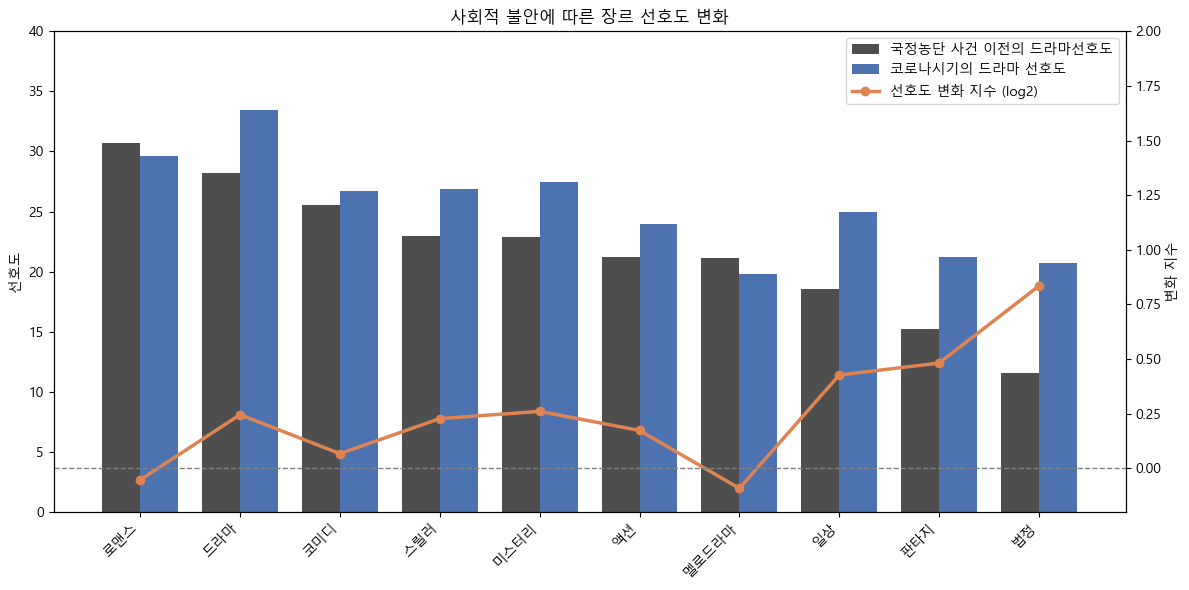

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# 0) 데이터 준비
df = scores[["국정농단 사건 이전의 드라마선호도", "코로나시기의 드라마 선호도"]].copy()
df = df[(df["국정농단 사건 이전의 드라마선호도"] > 0) & (df["코로나시기의 드라마 선호도"] > 0)]

# 1) (너가 원하면) 전체 TOP10 뽑기: 두 시기 중 최대값 기준
df_top10 = (
    df.sort_values("코로나시기의 드라마 선호도", ascending=False)
      .head(10)
      .copy()
)

# 2) 지표
df_top10["변화율(%)"] = (df_top10["코로나시기의 드라마 선호도"] - df_top10["국정농단 사건 이전의 드라마선호도"]) / df_top10["국정농단 사건 이전의 드라마선호도"] * 100
df_top10["log2_지수"] = np.log2(df_top10["코로나시기의 드라마 선호도"] / df_top10["국정농단 사건 이전의 드라마선호도"])

# ✅ 3) 핵심: 출시전(OTT출시전) 기준으로 내림차순 정렬
df_plot = df_top10.sort_values("국정농단 사건 이전의 드라마선호도", ascending=False).copy()

# ✅ 4) x축도 정렬된 df_plot에서 뽑기
genres = df_plot.index.to_list()
x = np.arange(len(genres))
w = 0.38

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(x - w/2, df_plot["국정농단 사건 이전의 드라마선호도"].to_numpy(), w, label="국정농단 사건 이전의 드라마선호도", color="#4E4E4E")
ax1.bar(x + w/2, df_plot["코로나시기의 드라마 선호도"].to_numpy(), w, label="코로나시기의 드라마 선호도", color="#4C72B0")

ax1.set_ylabel("선호도")
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha="right")
ax1.set_ylim(0,40)

ax2 = ax1.twinx()
ax2.plot(x, df_plot["log2_지수"].to_numpy(),
         color="#DD8452", marker="o", linewidth=2.5, label="선호도 변화 지수 (log2)")
ax2.set_ylabel("log2(코로나시기의 드라마 선호도 / 국정농단 사건 이전의 드라마선호도)")
ax2.axhline(0, linewidth=1, linestyle="--", color="gray")
ax2.set_ylabel("변화 지수")
ax2.set_ylim(-0.2, 2)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.title("사회적 불안에 따른 장르 선호도 변화")
plt.tight_layout()
plt.savefig("사회적 불안에 따른 드라마 선호도 비교.png",dpi=300, bbox_inches='tight')
plt.show()

- 10개의 고른 기준 - 코로나시기에 선호도가 가장 높은 10개를 기준으로
- 고른 이유 - 가장 최신의 컬럼을 기준으로 하면 베이스(농단 전 데이터)가 충분한 상태에서 변화했을거라 생각해서
- log2 이유 - 퍼센트로 보였을때 너무 100퍼센트가 넘어간 자료가 있으면 보기 불편할 수 있다고 생각해서
- 사회적 불안이 커지기 때문에 정의가 작동하는 세계, 질서를 직접 볼 수 있는 법정 드라마의 선호도가 크게 증가합
- 로맨스, 멜로 드라마는 어느정도 여유가 있어야 선호되는 장르, 높은 선호도임에도 불구하고 사회적 불안때문에 미래에 대한 기대가 적어지면서 자연스럽게 떨어짐
- 사회적 불안이 심화될수록 시청자들은 혼란이 해결되는 법정드라마를 선호하게 됨